# 02 · A hydrological model (GR4J)

Same GPU interface as `00_quickstart`, but the deterministic core is now **GR4J** — a
4-parameter lumped conceptual rainfall-runoff model — instead of the MLP.

GR4J reads two columns of `X`, precipitation `P` and potential evapotranspiration `PET`, both
in **mm/day**, and returns runoff in mm/day. Its four parameters (`X1..X4`) are *not*
constructor arguments — the optimiser owns them, so `GR4JModel()` is instantiated bare and GPU
searches them inside their physical ranges.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from foresight_gpu import GPURegressor
from foresight_gpu.models import GR4JModel
from foresight_gpu.metrics import get_metric
from foresight_gpu.metrics.probabilistic import reliability
from foresight_gpu.utils import plot_timeseries, plot_qq

### A synthetic catchment

A seasonal wet/dry rainfall regime and a smooth PET cycle drive GR4J under known "true"
parameters. The observations add **multiplicative** log-normal error, so the spread grows
with flow — the form discharge error usually takes.

In [2]:
rng = np.random.default_rng(0)
n = 1200                                    # ~3.3 years of daily steps
doy = np.arange(n) % 365

wet = 1.0 + 0.8 * np.sin(2 * np.pi * doy / 365)
precip = rng.gamma(0.6, 6.0, size=n) * wet
pet = 3.0 + 1.5 * np.sin(2 * np.pi * (doy - 30) / 365)
X = np.column_stack([precip, pet])          # col 0 = P, col 1 = PET, chronological order

true_params = np.array([350.0, 0.5, 90.0, 1.7])   # X1 [mm], X2 [mm], X3 [mm], X4 [d]
q_true = GR4JModel().forward(X, true_params).ravel()
y = q_true * np.exp(0.25 * rng.standard_normal(n))

### Fit and predict

`force_positive=True` because discharge cannot be negative. GR4J initialises its stores at
the start of every `forward` call; here the "truth" starts from the same stores, so no
spin-up is needed. On real data, expect the first months to carry that initial transient.

reliability alpha = 0.992


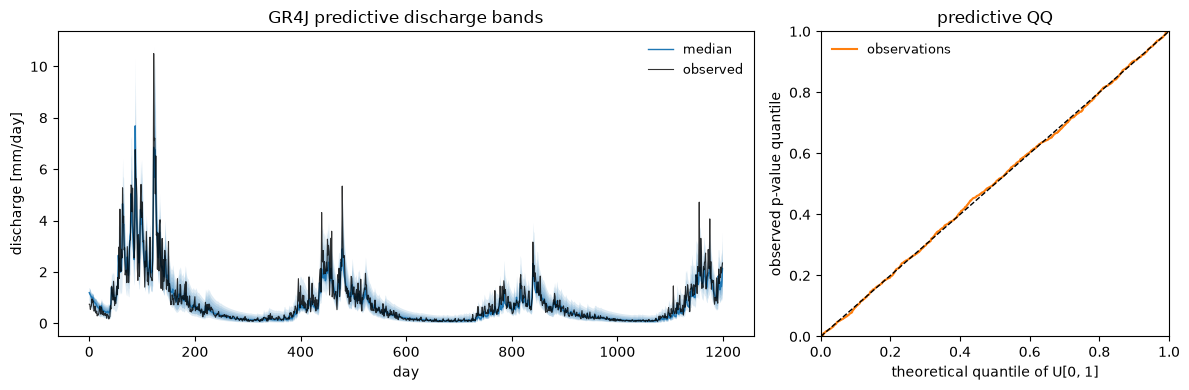

In [3]:
gpu = GPURegressor(model=GR4JModel(), metric='nse', force_positive=True,
                   population=400, n_iter=80, random_state=0)
gpu.fit(X, y)

bands = gpu.predict_quantiles(X)
pvalues = gpu.predictive_pvalues(X, y)
print('reliability alpha =', round(reliability(pvalues), 3))

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
plot_timeseries(bands, gpu.ensemble_.quantiles, observed=y, ax=a0)
a0.set_title('GR4J predictive discharge bands', pad=42)
a0.set_xlabel('day')
a0.set_ylabel('discharge [mm/day]')
plot_qq(pvalues, ax=a1)
a1.set_title('predictive QQ')
fig.tight_layout()

### What the parameters look like

Every ensemble member *is* an interpretable parameter set, each carrying its own
non-exceedance level. `ensemble_.params` is therefore a **distribution** of `X1..X4`, spread
deliberately across the probability range — not a confidence interval around one
calibration.

In [4]:
params = gpu.ensemble_.params
nse_loss = get_metric('nse').loss                  # 1 - NSE
losses = nse_loss(GR4JModel().forward(X, params), y)
best = int(np.argmin(losses))
lo, hi = np.percentile(params, [10, 90], axis=0)

print(f'{"":>9}  {"true":>8}  {"best fit":>8}   ensemble p10-p90')
for k, name in enumerate(['X1 [mm]', 'X2 [mm]', 'X3 [mm]', 'X4 [d]']):
    print(f'{name:>9}  {true_params[k]:8.2f}  {params[best, k]:8.2f}   '
          f'{lo[k]:8.2f} - {hi[k]:8.2f}')

true_loss = float(nse_loss(GR4JModel().forward(X, true_params), y)[0])
print(f'\ntraining loss (1 - NSE)  best member {losses[best]:.4f}   true params {true_loss:.4f}')

               true  best fit   ensemble p10-p90
  X1 [mm]    350.00    323.87     236.62 -   371.09
  X2 [mm]      0.50      1.25      -2.76 -     3.29
  X3 [mm]     90.00    171.02     109.22 -   161.20
   X4 [d]      1.70      1.53       1.48 -     1.74

training loss (1 - NSE)  best member 0.1122   true params 0.0877


Two caveats for real data:

- The wide `ensemble_.params` spread is **not** an error bar on a calibration: the
  population is spread across non-exceedance levels on purpose, which is what makes the bands
  reliable.
- If the true parameters fit the noisy observations better than the best member, the search
  budget (`population`, `n_iter`) is the binding constraint, not the noise. Check this before
  reading physical meaning into `X1..X4`.

Swapping `MLPModel` for `GR4JModel` changed nothing about the GPU interface — only the number
and meaning of the input columns.

**Notebooks:** `00_quickstart` · `01_custom_model` · `02_gr4j` · `03_extra_diagnostics` ·
`04_uncertainty_experiments`